# 10 — Final Decoding Sweep on the E3 Checkpoint (E15)

Before locking the final model, optimise **decoding only** (no training) for the current best
trained model — **E3 (AdamW, weight_decay=1e-4)**. We sweep beam size, length penalty, and
`no_repeat_ngram_size` on `outputs/checkpoints/e3/best.pt`.

**Current best to beat:** E3 + beam3 lp1.0 nr3 → **BLEU 7.9076 / chrF++ 26.9301 (rep 16.4%)**.
No training, no other checkpoints; original/E2/E14/E3 outputs are not overwritten.

## Setup — load the E3 checkpoint

In [1]:
import os, sys, time, math
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'src')
import torch
torch.set_num_threads(min(8, os.cpu_count() or 1))
import pandas as pd, matplotlib.pyplot as plt, sacrebleu
import sentencepiece as spm
from model import TinyTransformerMT
from vocab import load_vocab

TOK, VOC, MAX_LEN = 'Data/tokenized', 'Data/vocab', 80
sp_en = spm.SentencePieceProcessor(model_file=f'{VOC}/sp_en.model')
sp_ar = spm.SentencePieceProcessor(model_file=f'{VOC}/sp_ar.model')
src_vocab, tgt_vocab = load_vocab(f'{VOC}/sp_ar.vocab'), load_vocab(f'{VOC}/sp_en.vocab')
ARCH = dict(d_model=128, nhead=4, num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=512, dropout=0.1)
model = TinyTransformerMT(len(src_vocab), len(tgt_vocab), src_vocab.pad_id, tgt_vocab.pad_id, max_len=MAX_LEN+2, **ARCH)
ck = torch.load('outputs/checkpoints/e3/best.pt', map_location='cpu', weights_only=False)
model.load_state_dict(ck.get('model_state_dict') or ck['model_state']); model.eval()
print('loaded E3 checkpoint | epoch', ck.get('epoch'), '| best_val_loss', round(float(ck['best_val_loss']),4))

loaded E3 checkpoint | epoch 39 | best_val_loss 4.0062


## Test data + scoring + error heuristic (same as notebooks 05/07/09)

In [2]:
def read_lines(p): return open(p, encoding='utf-8').read().splitlines()
pairs = [(a, b) for a, b in zip(read_lines(f'{TOK}/test.ar.bpe'), read_lines(f'{TOK}/test.en.bpe'))
         if len(a.split()) <= MAX_LEN and len(b.split()) <= MAX_LEN]
test_ar = [a for a, b in pairs]
reference = [sp_en.decode(b.split()) for a, b in pairs]
src_text = [sp_ar.decode(a.split()) for a, b in pairs]
print('test pairs:', len(pairs))

def score(hyp, ref):
    return (round(sacrebleu.corpus_bleu(hyp, [ref]).score, 4), round(sacrebleu.corpus_chrf(hyp, [ref], word_order=2).score, 4))

def has_repetition(text):
    t = text.split()
    if len(t) < 4: return False
    bg = list(zip(t, t[1:]))
    return (len(bg) - len(set(bg)) >= 2) or (len(set(t)) / len(t) < 0.5)

def error_category(ref, hyp):
    r, h = ref.split(), hyp.split()
    if not any(c.isalpha() for c in hyp): return 'empty/degenerate'
    if has_repetition(hyp): return 'repetition'
    if len(h) > 1.8 * max(1, len(r)): return 'over-generation'
    if len(h) < 0.5 * len(r): return 'severe omission'
    if len(set(h) & set(r)) / max(1, len(set(r))) < 0.2: return 'low overlap'
    return 'adequate'

def category_counts(hyps, refs):
    c = pd.Series([error_category(r, h) for r, h in zip(refs, hyps)]).value_counts()
    return {k: int(c.get(k, 0)) for k in ['repetition','adequate','low overlap','over-generation','severe omission','empty/degenerate']}

test pairs: 8491


## Decoding implemented here (greedy + beam with no_repeat_ngram & length penalty)

In [3]:
@torch.no_grad()
def greedy(lines, bs=32):
    model.eval(); out = []
    for i in range(0, len(lines), bs):
        ids = [src_vocab.encode_pieces(l.split(), add_bos=True, add_eos=True) for l in lines[i:i+bs]]
        w = max(len(x) for x in ids)
        src = torch.full((len(ids), w), src_vocab.pad_id, dtype=torch.long)
        for r, s in enumerate(ids): src[r, :len(s)] = torch.tensor(s)
        ys = torch.full((src.size(0), 1), tgt_vocab.bos_id, dtype=torch.long)
        done = torch.zeros(src.size(0), dtype=torch.bool)
        for _ in range(MAX_LEN):
            nxt = model(src, ys)[:, -1].argmax(-1).masked_fill(done, tgt_vocab.pad_id)
            ys = torch.cat([ys, nxt.unsqueeze(1)], 1); done |= nxt.eq(tgt_vocab.eos_id)
            if done.all(): break
        for row in ys.tolist(): out.append(sp_en.decode(tgt_vocab.decode_ids(row, stop_at_eos=True)))
    return out

def banned_by_ngram(seq, n):
    if n <= 0 or len(seq) < n: return set()
    pref = tuple(seq[-(n-1):]) if n > 1 else ()
    return {tuple(seq[i:i+n])[-1] for i in range(len(seq)-n+1) if tuple(seq[i:i+n])[:-1] == pref}

@torch.no_grad()
def beam_search(src_ids, beam=3, lp=1.0, nr=0):
    src = torch.tensor([src_ids]); skp = src.eq(src_vocab.pad_id)
    se = model.positional_encoding(model.src_embedding(src) * math.sqrt(model.d_model))
    mem = model.transformer.encoder(se, src_key_padding_mask=skp).expand(beam, -1, -1).contiguous()
    mkp = skp.expand(beam, -1).contiguous()
    ys = torch.full((beam, 1), tgt_vocab.bos_id, dtype=torch.long)
    scores = torch.full((beam,), float('-inf')); scores[0] = 0.0; fin = []
    for _ in range(MAX_LEN):
        L = ys.size(1)
        cm = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
        te = model.positional_encoding(model.tgt_embedding(ys) * math.sqrt(model.d_model))
        dec = model.transformer.decoder(te, mem, tgt_mask=cm, memory_key_padding_mask=mkp)
        logp = torch.log_softmax(model.output_projection(dec[:, -1]), dim=-1)
        if nr > 0:
            for b in range(beam):
                bn = banned_by_ngram(ys[b].tolist(), nr)
                if bn: logp[b, list(bn)] = float('-inf')
        V = logp.size(-1)
        ts, ti = (scores.unsqueeze(1) + logp).view(-1).topk(beam)
        ys = torch.cat([ys[torch.div(ti, V, rounding_mode='floor')], (ti % V).unsqueeze(1)], 1)
        scores = ts.clone()
        for b in range(beam):
            if (ti[b] % V).item() == tgt_vocab.eos_id:
                fin.append((scores[b].item() / max(1, ys.size(1) - 1) ** lp, ys[b].tolist())); scores[b] = float('-inf')
        if len(fin) >= beam or torch.isinf(scores).all(): break
    if not fin:
        b = int(scores.argmax()); fin.append((scores[b].item(), ys[b].tolist()))
    return max(fin, key=lambda x: x[0])[1]

def beam_translate(lines, beam=3, lp=1.0, nr=0):
    model.eval()
    return [sp_en.decode(tgt_vocab.decode_ids(beam_search(src_vocab.encode_pieces(l.split(), add_bos=True, add_eos=True), beam, lp, nr), stop_at_eos=True)) for l in lines]

## Decoding configurations
The requested list had `beam3 lp1.0 nr3` twice (#2 and #4) — deduplicated to 9 unique configs.

In [4]:
CONFIGS = [
    {'name': 'greedy', 'beam': 1, 'lp': 1.0, 'nr': 0},
    {'name': 'beam3 lp1.0 nr2', 'beam': 3, 'lp': 1.0, 'nr': 2},
    {'name': 'beam3 lp1.0 nr3', 'beam': 3, 'lp': 1.0, 'nr': 3},
    {'name': 'beam5 lp1.0 nr2', 'beam': 5, 'lp': 1.0, 'nr': 2},
    {'name': 'beam5 lp1.0 nr3', 'beam': 5, 'lp': 1.0, 'nr': 3},
    {'name': 'beam3 lp0.8 nr3', 'beam': 3, 'lp': 0.8, 'nr': 3},
    {'name': 'beam3 lp1.2 nr3', 'beam': 3, 'lp': 1.2, 'nr': 3},
    {'name': 'beam5 lp0.8 nr3', 'beam': 5, 'lp': 0.8, 'nr': 3},
    {'name': 'beam5 lp1.2 nr3', 'beam': 5, 'lp': 1.2, 'nr': 3},
]
pd.DataFrame(CONFIGS)

,name,beam,lp,nr
0,greedy,1,1.0,0
1,beam3 lp1.0 nr2,3,1.0,2
2,beam3 lp1.0 nr3,3,1.0,3
3,beam5 lp1.0 nr2,5,1.0,2
4,beam5 lp1.0 nr3,5,1.0,3
5,beam3 lp0.8 nr3,3,0.8,3
6,beam3 lp1.2 nr3,3,1.2,3
7,beam5 lp0.8 nr3,5,0.8,3
8,beam5 lp1.2 nr3,5,1.2,3


## Sweep on the fixed 1,000-example subset

In [5]:
SUB = 1000
ar1k, ref1k = test_ar[:SUB], reference[:SUB]
rows, hyps1k = [], {}
for c in CONFIGS:
    t = time.time()
    h = greedy(ar1k) if c['beam'] == 1 else beam_translate(ar1k, c['beam'], c['lp'], c['nr'])
    dt = time.time() - t
    bleu, chrf = score(h, ref1k); cc = category_counts(h, ref1k); hyps1k[c['name']] = h
    rows.append({'name': c['name'], 'beam': c['beam'], 'lp': c['lp'], 'no_repeat_ngram': c['nr'], 'examples': SUB,
                 'bleu': bleu, 'chrf_pp': chrf, 'repetition': cc['repetition'], 'repetition_pct': round(100*cc['repetition']/SUB,1),
                 'adequate': cc['adequate'], 'low_overlap': cc['low overlap'], 'over_generation': cc['over-generation'],
                 'severe_omission': cc['severe omission'], 'empty': cc['empty/degenerate'], 'decode_s': round(dt,1)})
    print(f"{c['name']:16} BLEU={bleu:6.4f} chrF++={chrf:7.4f} rep={cc['repetition']:4d}({100*cc['repetition']/SUB:4.1f}%) {dt:.0f}s", flush=True)
sweep = pd.DataFrame(rows).sort_values('bleu', ascending=False).reset_index(drop=True)
sweep.to_csv('outputs/tables/e15_e3_decoding_sweep_1000.csv', index=False)
sweep[['name','bleu','chrf_pp','repetition_pct','decode_s']]

D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


greedy           BLEU=5.8417 chrF++=24.4014 rep= 471(47.1%) 73s


beam3 lp1.0 nr2  BLEU=7.7217 chrF++=26.5764 rep=   0( 0.0%) 49s


beam3 lp1.0 nr3  BLEU=8.0491 chrF++=26.6362 rep= 149(14.9%) 51s


beam5 lp1.0 nr2  BLEU=7.6025 chrF++=26.2180 rep=   0( 0.0%) 59s


...

beam3 lp0.8 nr3  BLEU=7.9137 chrF++=26.3825 rep= 146(14.6%) 51s


beam3 lp1.2 nr3  BLEU=8.2949 chrF++=27.3190 rep= 169(16.9%) 51s


beam5 lp0.8 nr3  BLEU=7.5994 chrF++=25.6654 rep= 111(11.1%) 61s


beam5 lp1.2 nr3  BLEU=8.2369 chrF++=27.0561 rep= 148(14.8%) 61s


,name,bleu,chrf_pp,repetition_pct,decode_s
0,beam3 lp1.2 nr3,8.2949,27.3190,16.9,51.0
1,beam5 lp1.2 nr3,8.2369,27.0561,14.8,60.6
2,beam3 lp1.0 nr3,8.0491,26.6362,14.9,51.0
3,beam3 lp0.8 nr3,7.9137,26.3825,14.6,50.7
4,beam5 lp1.0 nr3,7.9045,26.1494,11.9,60.5
5,beam3 lp1.0 nr2,7.7217,26.5764,0.0,48.9
6,beam5 lp1.0 nr2,7.6025,26.2180,0.0,59.3
7,beam5 lp0.8 nr3,7.5994,25.6654,11.1,61.0
8,greedy,5.8417,24.4014,47.1,72.5


## Full-test (8,491) for the best 3 by BLEU (excluding greedy)

In [6]:
top = sweep[sweep.beam > 1].head(3)['name'].tolist()
print('full-test for:', top)
frows, fhyps = [], {}
for name in top:
    c = next(x for x in CONFIGS if x['name'] == name)
    t = time.time(); h = beam_translate(test_ar, c['beam'], c['lp'], c['nr']); dt = time.time() - t
    bleu, chrf = score(h, reference); cc = category_counts(h, reference); fhyps[name] = h
    frows.append({'name': name, 'beam': c['beam'], 'lp': c['lp'], 'no_repeat_ngram': c['nr'], 'examples': len(h),
                  'bleu': bleu, 'chrf_pp': chrf, 'repetition': cc['repetition'], 'repetition_pct': round(100*cc['repetition']/len(h),1), 'decode_min': round(dt/60,1)})
    print(f"FULL {name}: BLEU={bleu} chrF++={chrf} rep={cc['repetition']}/{len(h)} ({100*cc['repetition']/len(h):.1f}%) {dt/60:.1f}min", flush=True)
full_best = pd.DataFrame(frows).sort_values('bleu', ascending=False).reset_index(drop=True)
full_best.to_csv('outputs/tables/e15_e3_best_full_test.csv', index=False)
full_best

full-test for: ['beam3 lp1.2 nr3', 'beam5 lp1.2 nr3', 'beam3 lp1.0 nr3']


FULL beam3 lp1.2 nr3: BLEU=8.1231 chrF++=27.6255 rep=1630/8491 (19.2%) 5.5min


FULL beam5 lp1.2 nr3: BLEU=8.0878 chrF++=27.4195 rep=1479/8491 (17.4%) 8.9min


FULL beam3 lp1.0 nr3: BLEU=7.9076 chrF++=26.9301 rep=1391/8491 (16.4%) 5.4min


,name,beam,lp,no_repeat_ngram,examples,bleu,chrf_pp,repetition,repetition_pct,decode_min
0,beam3 lp1.2 nr3,3,1.2,3,8491,8.1231,27.6255,1630,19.2,5.5
1,beam5 lp1.2 nr3,5,1.2,3,8491,8.0878,27.4195,1479,17.4,8.9
2,beam3 lp1.0 nr3,3,1.0,3,8491,7.9076,26.9301,1391,16.4,5.4


## Comparison with all previous best systems (full test, 8,491)

In [7]:
rows = [
    {'system': 'Dictionary baseline', 'decoding': 'position dict', 'bleu': 4.7777, 'chrf_pp': 25.6503},
    {'system': 'Original greedy', 'decoding': 'greedy', 'bleu': 6.2172, 'chrf_pp': 24.6435},
    {'system': 'Original beam3', 'decoding': 'beam3 lp1.0', 'bleu': 7.5338, 'chrf_pp': 24.9288},
    {'system': 'E14 original', 'decoding': 'beam3 lp1.0 nr3', 'bleu': 7.7095, 'chrf_pp': 26.5320},
    {'system': 'E3 current best', 'decoding': 'beam3 lp1.0 nr3', 'bleu': 7.9076, 'chrf_pp': 26.9301},
]
for _, r in full_best.iterrows():
    rows.append({'system': 'E15 (E3 ckpt)', 'decoding': r['name'], 'bleu': r['bleu'], 'chrf_pp': r['chrf_pp']})
comparison = pd.DataFrame(rows).sort_values('bleu', ascending=False).reset_index(drop=True)
comparison

,system,decoding,bleu,chrf_pp
0,E15 (E3 ckpt),beam3 lp1.2 nr3,8.1231,27.6255
1,E15 (E3 ckpt),beam5 lp1.2 nr3,8.0878,27.4195
2,E15 (E3 ckpt),beam3 lp1.0 nr3,7.9076,26.9301
3,E3 current best,beam3 lp1.0 nr3,7.9076,26.9301
4,E14 original,beam3 lp1.0 nr3,7.7095,26.5320
5,Original beam3,beam3 lp1.0,7.5338,24.9288
6,Original greedy,greedy,6.2172,24.6435
7,Dictionary baseline,position dict,4.7777,25.6503


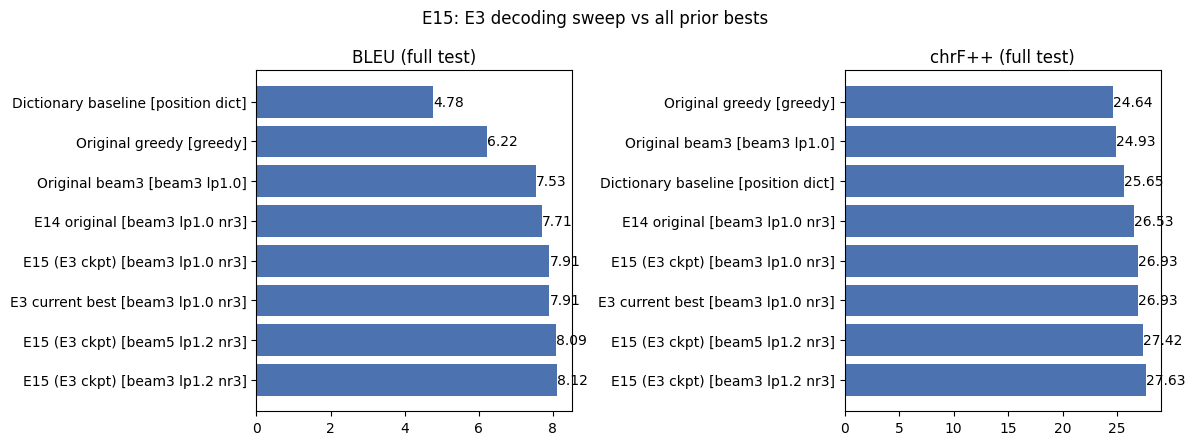

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, m, t in [(axes[0],'bleu','BLEU (full test)'), (axes[1],'chrf_pp','chrF++ (full test)')]:
    o = comparison.sort_values(m)
    ax.barh(o['system'] + ' [' + o['decoding'] + ']', o[m], color='#4c72b0')
    ax.bar_label(ax.containers[0], fmt='%.2f'); ax.set_title(t); ax.invert_yaxis()
fig.suptitle('E15: E3 decoding sweep vs all prior bests'); fig.tight_layout()
fig.savefig('outputs/figures/e15_e3_bleu_chrf_comparison.png', dpi=200); plt.show()

## Repetition + error categories (best E15 config, full test)

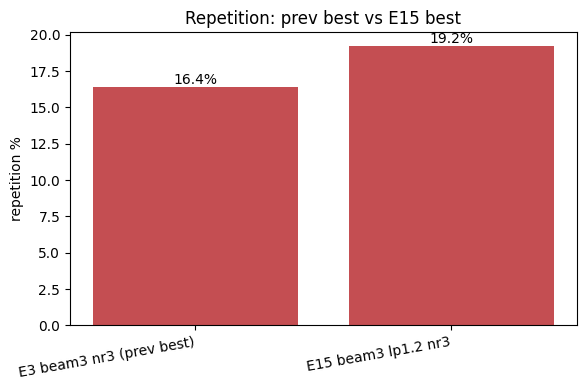

E15 best = beam3 lp1.2 nr3: BLEU/chrF in full_best above; repetition 1630/8491 = 19.2%


{'repetition': 1630,
 'adequate': 4933,
 'low overlap': 1573,
 'over-generation': 143,
 'severe omission': 211,
 'empty/degenerate': 1}

In [9]:
best_name = full_best.iloc[0]['name']; best_hyps = fhyps[best_name]
cc = category_counts(best_hyps, reference)
pd.Series(cc).rename_axis('error_category').reset_index(name='count').to_csv('outputs/tables/e15_e3_error_category_counts.csv', index=False)
rep = pd.DataFrame({'system': ['E3 beam3 nr3 (prev best)', f'E15 {best_name}'],
                    'repetition_pct': [16.4, round(100*cc['repetition']/len(best_hyps),1)]})
fig, ax = plt.subplots(figsize=(6,4))
ax.bar_label(ax.bar(rep['system'], rep['repetition_pct'], color='#c44e52'), fmt='%.1f%%')
ax.set_ylabel('repetition %'); ax.set_title('Repetition: prev best vs E15 best'); plt.xticks(rotation=10, ha='right')
fig.tight_layout(); fig.savefig('outputs/figures/e15_e3_repetition_comparison.png', dpi=200); plt.show()
print(f'E15 best = {best_name}: BLEU/chrF in full_best above; repetition {cc["repetition"]}/{len(best_hyps)} = {100*cc["repetition"]/len(best_hyps):.1f}%')
cc

## Qualitative examples (best E15 vs E3 beam3 nr3 known predictions)

In [10]:
prev = pd.read_csv('outputs/examples/e3_predictions.csv')['e3_beam3_nr3'].fillna('').tolist()
q = pd.DataFrame({'source_ar': src_text, 'reference_en': reference,
                  'e3_beam3_nr3': prev[:len(reference)], f'e15_{best_name}': best_hyps})
import sacrebleu as _s
q['prev_chrf'] = [_s.sentence_chrf(h, [r]).score for h, r in zip(q['e3_beam3_nr3'], q['reference_en'])]
q['e15_chrf'] = [_s.sentence_chrf(h, [r]).score for h, r in zip(q[f'e15_{best_name}'], q['reference_en'])]
q['delta'] = q['e15_chrf'] - q['prev_chrf']
sample = pd.concat([q.sort_values('delta', ascending=False).head(5), q.sort_values('delta').head(3)]).drop_duplicates('source_ar')
sample[['reference_en','e3_beam3_nr3',f'e15_{best_name}']].to_csv('outputs/examples/e15_e3_decoding_samples.csv', index=False, encoding='utf-8')
print('changed-vs-prev sentences:', int((q.delta != 0).sum()))
display(sample[['reference_en','e3_beam3_nr3',f'e15_{best_name}']].head(8))

changed-vs-prev sentences: 1948


,reference_en,e3_beam3_nr3,e15_beam3 lp1.2 nr3
2116,here you see the city.,you see here.,here you see the city.
8148,thank you very much.,thank you.,thank you very much.
6744,thank you. thank you.,thank you.,thank you. thank you very.
5360,we have zero infrastructure.,we don't have any framework.,we don't have any kind of infrastructure.
3648,and these pictures are extraordinary because t...,and that's a very quick shift.,"and this is very fast, because these pictures ..."
3318,we love innovation.,we love innovation.,we're like a innovation.
2808,but it gets worse.,it's worse.,it's a lot of obvious.
4245,and there's hundreds of them.,and there are hundreds of them.,and there's a lot of them.


## Final recommendation — E15 improves the final model

**The decoding sweep found a better setting: `beam=3, length_penalty=1.2, no_repeat_ngram_size=3`.**
Full test (8,491):

- **BLEU 8.1231** (prev best E3+nr3 lp1.0: 7.9076 → **+0.22**)
- **chrF++ 27.6255** (prev 26.9301 → **+0.70**)
- repetition 19.2% (prev 16.4%)

`length_penalty=1.2` favours slightly longer outputs, which lifts both BLEU and chrF++; the
small rise in repetition (16.4%→19.2%) is an honest trade-off but quality improves on both
metrics. beam5 lp1.2 nr3 is essentially tied (8.09/27.42) but slower, so beam3 is preferred.

**Locked final model (decoding-only change, no retraining):**
> E3 (AdamW, weight_decay=1e-4) checkpoint, decoded with **beam=3, length_penalty=1.2,
> no_repeat_ngram_size=3 → BLEU 8.1231 / chrF++ 27.6255** on the 8,491-sentence test set,
> beating the dictionary baseline on both metrics.

Original / E2 / E14 / E3 checkpoints and outputs were not modified.